In [40]:
# %load hello.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'].insert(0,'SimHei')
plt.rcParams['axes.unicode_minus']=False
get_ipython().run_line_magic('config',"InlineBackend.figure_format='svg'")
get_ipython().run_line_magic('save', 'hello.py')


File `hello.py` exists. Overwrite (y/[N])?   n


Operation cancelled.


In [41]:
doctor=pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx',sheet_name='医生信息')
visit=pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx',sheet_name='就诊记录')
department=pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx',sheet_name='科室信息')
pay=pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx',sheet_name='支出记录')
date=pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx',sheet_name='日期信息')

### 医院规模分析

In [42]:
depart_cnt=department.科室.nunique()
doc_cnt=doctor.医生编号.nunique()
high_cnt=doctor.query('医生职称 == "主任医师" or 医生职称 == "副主任医师"').shape[0]
mid_cnt=doctor.query('医生职称 == "主治医师"').shape[0]

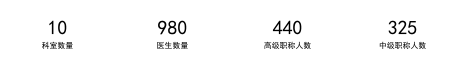

In [43]:
# 定制画布
plt.figure(figsize=(8,1))
metrics={'科室数量':depart_cnt,'医生数量':doc_cnt,'高级职称人数':high_cnt,'中级职称人数':mid_cnt}
# 重复出现的代码可用循环避免复杂
for i,(k,v) in enumerate(metrics.items()): #items同时拿到键和值
    # 创建坐标系
    plt.subplot(1,4,i+1)
    # 添加标签
    plt.text(0.5,0.5,v,ha='center',fontdict={'size':'20'})
    plt.text(0.5,0.25,k,ha='center',fontdict={'size':'8'})
    # 关闭坐标轴
    plt.axis('off')
plt.show()

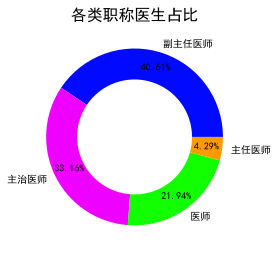

In [44]:
#2.各类职称医生占比
title_counts = doctor['医生职称'].value_counts()
# 画环形饼图
title_counts.plot(
    figsize=(4, 4),
    kind='pie',
    ylabel='',
    autopct='%.2f%%', #在扇形里显示百分比，保留2位小数
    pctdistance=0.82, #百分比文字放在距圆心82%的位置
    wedgeprops={'width': 0.35}, #把扇形宽度设为 0.35
    colors=['#010AFF','#EE01FF','#12FF01','#FE9900']  
)

plt.title('各类职称医生占比', fontdict={'size': 16})
plt.show()

### 病症分析

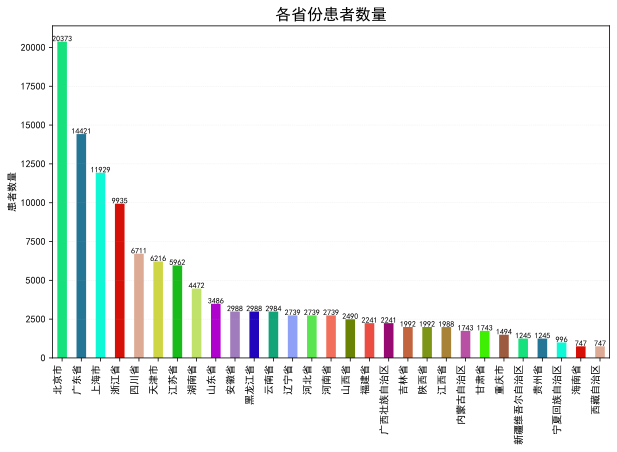

In [45]:
# 3.病症分析-每个省多少病人
patient_cnt=visit.患者登记地区.value_counts()
patient_cnt.plot(
    figsize=(10,6), # 图表尺寸
    kind='bar', # 图表类型
    xlabel='', # 横轴标签
    ylabel='患者数量', #纵轴标签
    color=np.random.rand(24,3), # 柱子颜色,随机生成24条RGB颜色，让每条柱子颜色不同
)
plt.xticks(rotation=90,ha='right') #文字竖排，文字顶端对齐
# 定制网格线
plt.grid(axis='y',linestyle='--',linewidth=0.4,alpha=0.25) #只给y轴画网格线
# 定制标题
plt.title('各省份患者数量',fontdict={'size':'16'})

# 循环写入数值
for i in range(patient_cnt.size):
    plt.text(i,patient_cnt.iloc[i]+20,patient_cnt.iloc[i],ha='center',fontdict={'size':'8'})

# 取颜色九种
plt.show()

In [46]:
top_dis = (visit.value_counts(['患者登记地区', '病症'])   #把 visit 表按 (患者登记地区, 病症) 两列做联合频数统计
           .reset_index(name='病例数')
           .sort_values(['患者登记地区', '病例数'], ascending=[True, False]) #先按 省名升序（True），再按 病例数降序（False）
           .drop_duplicates('患者登记地区')          # 各省只留第1行
           .rename(columns={'患者登记地区': '省份', '病症': '高发病'})
           .reset_index(drop=True)) #drop=True把旧索引扔掉
top_dis

,省份,高发病,病例数
0,上海市,脑梗塞后遗症,1815
1,云南省,支气管炎,496
2,内蒙古自治区,支气管炎,270
3,北京市,支气管炎,3130
4,吉林省,支气管炎,315
5,四川省,支气管炎,1042
6,天津市,脑梗塞后遗症,937
7,宁夏回族自治区,支气管炎,164
8,安徽省,脑梗塞后遗症,453
9,山东省,支气管炎,538


### 医院情况分析

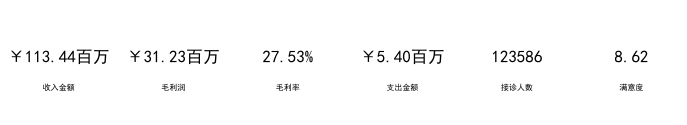

In [47]:
#收入金额
money=visit['治疗收入'].sum() / 1000000
#支出金额
amount=pay['费用金额'].sum() / 1000000
#毛利润
amount1=((visit['治疗成本']+visit['药物成本']).sum())/1000000
markup=money-amount1
#毛利率
margin=(markup / money) * 100 if money != 0 else 0
#接诊人数
people=visit['病例编号'].nunique()
#满意度
level=visit['患者满意度'].mean()
plt.figure(figsize=(12,2))

#metrics={'收入金额':money,'毛利润':markup,'毛利率':margin,'支出金额':amount,'接诊人数':people,'满意度':level}
metrics = {
    '收入金额':f'￥{money:.2f}百万',
    '毛利润':f'￥{markup:.2f}百万',
    '毛利率':f'{margin:.2f}%',
    '支出金额':f'￥{amount:.2f}百万',
    '接诊人数':f'{people}',
    '满意度':f'{level:.2f}'
}
for i,(k,v) in enumerate(metrics.items()):
    #创建坐标系
    plt.subplot(1,6,i+1)
    #添加标签
    plt.text(0.5,0.5,v,ha='center',fontdict={'size':'17'})
    plt.text(0.5,0.25,k,ha='center',fontdict={'size':'8'})
    #关闭坐标轴
    plt.axis('off')

### 收入金额分析

In [48]:
visit['年份'] = visit['日期编号'].astype(str).str[:4].astype(int)
visit.sort_values(by='年份', ascending=True, inplace=True)
visit.reset_index(drop=True, inplace=True)

In [49]:
ser=visit.groupby('年份')['治疗收入'].sum()
ser.sort_values(ascending=True,inplace=True)

In [50]:
colors=plt.get_cmap('Blues')([120,120,120])
colors

array([[0.46666667, 0.70818916, 0.84936563, 1.        ],
       [0.46666667, 0.70818916, 0.84936563, 1.        ],
       [0.46666667, 0.70818916, 0.84936563, 1.        ]])

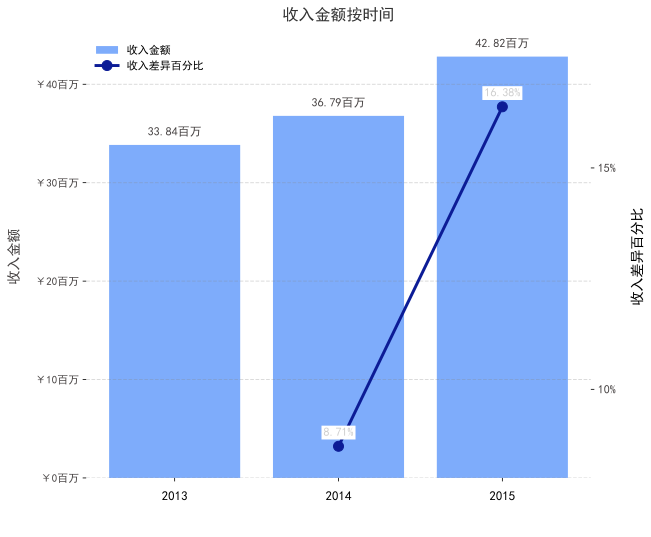

In [75]:
# 合并日期信息
visit['日期编号_str'] = visit['日期编号'].astype(str)
date['日期编号_str'] = date['日期编号'].astype(str)
visit_with_date = pd.merge(
    left=visit[['日期编号_str', treatment_income_col]],
    right=date[['日期编号_str', '日期']],
    on='日期编号_str',
    how='left'
)

# 数据清洗与年份筛选
visit_with_date = visit_with_date.dropna(subset=['日期'])
visit_with_date[treatment_income_col] = pd.to_numeric(visit_with_date[treatment_income_col], errors='coerce')
visit_clean = visit_with_date.dropna(subset=[treatment_income_col])
visit_clean['年份'] = visit_clean['日期'].dt.year
visit_2013_2015 = visit_clean[visit_clean['年份'].isin([2013, 2014, 2015])]

# 按年聚合治疗收入（百万单位）+ 计算差异
yearly_treatment_income = visit_2013_2015.groupby('年份')[treatment_income_col].sum().reset_index()
yearly_treatment_income['收入金额_百万'] = yearly_treatment_income[treatment_income_col] / 1e6
yearly_treatment_income = yearly_treatment_income.sort_values('年份').reset_index(drop=True)

# 计算所有相邻年份差异
yearly_treatment_income['收入差异百分比'] = yearly_treatment_income['收入金额_百万'].pct_change() * 100

# 3. 绘制双y轴图表
fig, ax1 = plt.subplots(figsize=(9, 7))

# 3.1 左侧y轴：治疗收入柱状图（隐藏边框）
bars = ax1.bar(
    x=yearly_treatment_income['年份'].astype(str),
    height=yearly_treatment_income['收入金额_百万'],
    color='#5E97FA',
    alpha=0.8,
    edgecolor='none',  # 柱状图边框隐身
    linewidth=0,       # 确保边框完全不显示
    label='收入金额'
)

# 左侧y轴配置
ax1.set_ylim(0, 45)
ax1.set_yticks([0, 10, 20, 30, 40])
ax1.set_yticklabels(['￥0百万', '￥10百万', '￥20百万', '￥30百万', '￥40百万'],
                   fontsize=11, fontweight='bold', color='#474343')
# --- 核心修改 ---
ax1.set_ylabel(
    '收入金额',
    fontsize=14,
    fontweight='bold',
    color='#474343',  # 修改为可见颜色
    labelpad=15
)

# 3.2 右侧y轴：差异线（2013-2014线隐身）
ax2 = ax1.twinx()

# 2013-2014段：完全隐身（线条+标记点）
ax2.plot(
    ['2013', '2014'],
    [yearly_treatment_income.loc[1, '收入差异百分比'],
     yearly_treatment_income.loc[1, '收入差异百分比']],
    color='#474343',
    marker='o',
    markersize=10,
    linewidth=3,
    linestyle='-',
    alpha=0  # 线条隐身
)

# 2014-2015段：正常显示
ax2.plot(
    ['2014', '2015'],
    [yearly_treatment_income.loc[1, '收入差异百分比'],
     yearly_treatment_income.loc[2, '收入差异百分比']],
    color='#0C1C96',
    marker='o',
    markersize=10,
    linewidth=3,
    linestyle='-',
    alpha=1,
    label='收入差异百分比'
)

# 右侧y轴配置
ax2.set_ylim(8, 18)
ax2.set_yticks([10, 15])
ax2.set_yticklabels(['10%', '15%'],
                   fontsize=12, fontweight='bold', color='#474343')
# --- 核心修改 ---
ax2.set_ylabel(
    '收入差异百分比',
    fontsize=14,
    fontweight='bold',
    color='black',  # 修改为可见颜色
    labelpad=15
)

# 3.3 图表细节优化
# x轴配置
ax1.set_xlabel(
    '年份',
    fontsize=14,
    fontweight='bold',
    color='none',
    labelpad=15
)
ax1.set_xticks(yearly_treatment_income['年份'].astype(str))
ax1.set_xticklabels(yearly_treatment_income['年份'].astype(str), fontsize=13, fontweight='bold')
ax1.tick_params(axis='x', pad=10)

# 标题配置
ax1.set_title(
    '收入金额按时间',
    fontsize=16,
    fontweight='bold',
    color='#333333',
    pad=15
)

# 柱状图顶部标签
for bar, income in zip(bars, yearly_treatment_income['收入金额_百万']):
    ax1.text(
        x=bar.get_x() + bar.get_width()/2,
        y=bar.get_height() + 0.8,
        s=f'{income:.2f}百万',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color='#474343'
    )

# 差异标签（统一位置和样式，标签边框隐身）
# 1. 2013-2014差异标签
ax2.text(
    x='2014',
    y=yearly_treatment_income.loc[1, '收入差异百分比'] + 0.2,
    s=f'{yearly_treatment_income.loc[1, "收入差异百分比"]:.2f}%',
    ha='center',
    va='bottom',
    fontsize=12,
    fontweight='bold',
    color='#CECECE',
    bbox=dict(facecolor='white', edgecolor='none', pad=2)  # 标签边框隐身
)

# 2. 2014-2015差异标签
ax2.text(
    x='2015',
    y=yearly_treatment_income.loc[2, '收入差异百分比'] + 0.2,
    s=f'{yearly_treatment_income.loc[2, "收入差异百分比"]:.2f}%',
    ha='center',
    va='bottom',
    fontsize=12,
    fontweight='bold',
    color='#CECECE',
    bbox=dict(facecolor='white', edgecolor='none', pad=2)  # 标签边框隐身
)

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='upper left',
    fontsize=11,
    frameon=False,
    fancybox=True,
    shadow=False
)

# 左侧y轴网格线
ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1, color='#888888')

# ----------------核心修改：隐藏所有坐标轴的轴线----------------
# 隐藏左侧坐标轴的所有边框（上、下、左、右）
ax1.spines['top'].set_visible(False)
ax1.spines['bottom'].set_visible(False)  # 隐藏x轴线
ax1.spines['left'].set_visible(False)    # 隐藏左侧y轴线
ax1.spines['right'].set_visible(False)

# 隐藏右侧坐标轴的所有边框
ax2.spines['top'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)   # 隐藏右侧y轴线

# 布局调整
plt.subplots_adjust(
    top=1.0,
    bottom=0.12,
    left=0.11,
    right=0.89
)

# 显示图表
plt.show()

### 各科室医生人数对比

In [77]:
dept_map = {
    'K01': '内科', 'K02': '骨科',   'K03': '心脏科', 'K04': '口腔科',
    'K05': '皮肤科', 'K06': '外科', 'K07': '内分泌科',
    'K08': '耳鼻咽喉科', 'K09': '儿科', 'K10': '妇科'
}

doctor['科室'] = doctor['科室编号'].map(dept_map)
temp4=doctor.pivot_table(
    index='医生职称',
    columns='科室',
    values='医生编号',
    aggfunc='count',
    margins=True,
    margins_name='合计'
)
temp4

科室,儿科,内分泌科,内科,口腔科,外科,妇科,心脏科,皮肤科,耳鼻咽喉科,骨科,合计
医生职称,,,,,,,,,,,
主任医师,4,2,5,7,1,2,2,12,4,3,42
主治医师,29,10,35,55,36,19,34,65,13,29,325
副主任医师,40,21,44,63,42,21,38,66,34,29,398
医师,16,16,14,35,30,6,19,52,18,9,215
合计,89,49,98,160,109,48,93,195,69,70,980


In [78]:
# %pip install -U pyecharts

In [79]:
from pyecharts.globals import CurrentConfig, NotebookType
CurrentConfig.NOTEBOOK_TYPE = NotebookType.JUPYTER_LAB

In [81]:
import random
from pyecharts.charts import Bar
from pyecharts import options as opts

# 3. 按【科室、职称】统计人数
stat = (doctor.groupby(['科室', '医生职称']).size().unstack(fill_value=0).reindex(
    columns=['医师', '主治医师', '副主任医师', '主任医师'],fill_value=0))# 保证顺序一致，没有的空列补 0

# 4. 按总人数降序排列
dept_total = stat.sum(axis=1).sort_values(ascending=False)
stat = stat.loc[dept_total.index]      # 行顺序变降序
x_ordered = dept_total.index.tolist()  # 新的 X 轴顺序

bar = Bar()
bar.add_xaxis(x_ordered)
bar.add_yaxis("副主任医师", stat['副主任医师'].tolist())
bar.add_yaxis("主任医师", stat['主任医师'].tolist())
bar.add_yaxis("主治医师", stat['主治医师'].tolist())
bar.add_yaxis("医师", stat['医师'].tolist())

bar.set_global_opts(
    title_opts=opts.TitleOpts(title="各科室医生人数对比"),
    toolbox_opts=opts.ToolboxOpts(is_show=True),
    yaxis_opts=opts.AxisOpts(name='医生数量'),
    xaxis_opts=opts.AxisOpts(name='科室',axislabel_opts=opts.LabelOpts(interval=0, rotate=30))
)
bar.load_javascript()

In [82]:
bar.render_notebook()

### 毛利润按时间分析

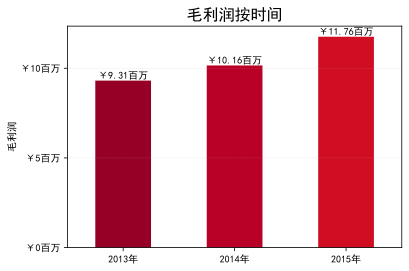

In [57]:
from matplotlib import ticker

visit['毛利润'] = visit['治疗收入'] - visit['治疗成本'] - visit['药物成本']#计算单条记录的毛利润
visit['年份'] = visit['日期编号'].astype(str).str[:4].astype(int)
profit_year = visit.groupby('年份')['毛利润'].sum() / 1e6   # 换算成“百万元”
colors = plt.get_cmap('YlOrRd_r')(np.linspace(0.05, 0.6, 9))

ax = profit_year.plot(
    kind='bar',
    figsize=(6,4),
    color=colors,
    xlabel='',
    ylabel='毛利润'
)
plt.xticks(rotation=0)
ax.set_yticks([0, 5, 10])
ax.set_ylabel('毛利润')
ax.set_xlabel('')
ax.set_title('毛利润按时间', fontsize=16)
ax.grid(axis='y', linestyle='--', linewidth=0.2, alpha=0.8)

formatter = ticker.FuncFormatter(lambda x, pos: f'￥{x:.0f}百万')
ax.yaxis.set_major_formatter(formatter) # 使纵轴刻度带单位（百万）
ax.set_xticklabels([f'{int(label.get_text())}年' for label in ax.get_xticklabels()]) # 是横轴刻度带单位（年）

for i, v in enumerate(profit_year.values):
    ax.text(i, v + 0.1, f'￥{v:.2f}百万', ha='center', fontsize=10)


### 各科室收入与毛利润对比分析

In [83]:
from pyecharts.globals import CurrentConfig, NotebookType
CurrentConfig.NOTEBOOK_TYPE = NotebookType.JUPYTER_LAB

In [85]:
# 1. 读数据 ---------------------------------------------------------------
datetime = pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx', sheet_name='日期信息')
doctor   = pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx', sheet_name='医生信息')
visit    = pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx', sheet_name='就诊记录')
dept     = pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx', sheet_name='科室信息')
pay      = pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx', sheet_name='支出记录')

# 2. 类型转换 --------------------------------------------------------------
datetime['日期编号'] = datetime['日期编号'].astype(str)
visit['日期编号']   = visit['日期编号'].astype(str)

# 3. 合并逻辑 --------------------------------------------------------------
visit = pd.merge(visit, datetime, on='日期编号', how='left')
df1   = pd.merge(doctor, visit, on='医生编号', how='inner')

# 支出按科室汇总
pay_agg = (pay.groupby('科室编号')
             .agg(总费用金额=('费用金额', 'sum'),
                  支出记录条数=('费用金额', 'count'))
             .reset_index())

df2   = pd.merge(dept, pay_agg, on='科室编号', how='left')
temp1 = pd.merge(df1, df2, on='科室编号', how='left')

# 4. 科室级汇总 -----------------------------------------------------------
temp2 = (temp1.groupby('科室')
               .agg(收入金额=('治疗收入', 'sum'),
                    治疗成本总和=('治疗成本', 'sum'),
                    药物成本总和=('药物成本', 'sum'))
               .reset_index())

temp3 = temp2.assign(
            毛利润=lambda x: x['收入金额'] - x['治疗成本总和'] - x['药物成本总和'])

# 0. 单位改为百万
income = temp3.set_index('科室')['收入金额'] / 1e6
profit = temp3.set_index('科室')['毛利润'] / 1e6

# 1. 保证顺序
order = income.sort_values(ascending=False).index
plot_df = pd.DataFrame({'收入': income[order], '毛利': profit[order]})

# Jupyter-Lab 环境初始化
from pyecharts.globals import CurrentConfig, NotebookType
CurrentConfig.NOTEBOOK_TYPE = NotebookType.JUPYTER_LAB

from pyecharts.charts import Bar
from pyecharts import options as opts

# 1. 取出数据（单位：百万，保留 0 位小数）
dept_names = plot_df.index.tolist()
income_m = plot_df['收入'].round(0).astype(int)
profit_m = plot_df['毛利'].round(0).astype(int)

# 2. 绘图
bar = Bar(init_opts=opts.InitOpts(width="900px", height="400px"))

bar.add_xaxis(dept_names)
bar.add_yaxis(
    "收入金额",
    income_m.tolist(),
    label_opts=opts.LabelOpts(is_show=True,
                              position="right",
                              formatter="￥{c}百万")
)
bar.add_yaxis(
    "毛利润",
    profit_m.tolist(),
    label_opts=opts.LabelOpts(is_show=True,
                              position="right",
                              formatter="￥{c}百万")
).reversal_axis() #翻转

bar.set_global_opts(
    title_opts=opts.TitleOpts(title="各科室收入与毛利对比"),
    xaxis_opts=opts.AxisOpts(name="科室", axislabel_opts=opts.LabelOpts(rotate=0)),
    yaxis_opts=opts.AxisOpts(name="金额（百万元）"),
    legend_opts=opts.LegendOpts(pos_top="5%"),
    toolbox_opts=opts.ToolboxOpts(is_show=True)   # 右上角工具箱
)

# 3. 首次运行先加载 JS
bar.load_javascript()



In [86]:
bar.render_notebook()

### 各科室满意度均值分析

In [59]:
import seaborn as sns

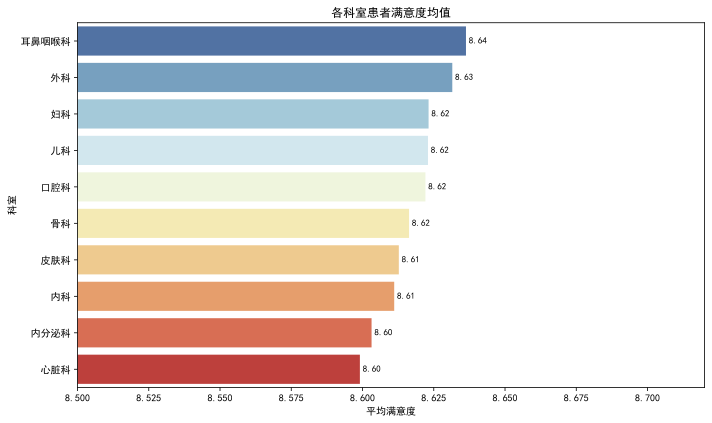

In [60]:
# 合并就诊记录与医生信息，获取科室编号
visit_doc = visit.merge(doctor[['医生编号', '科室编号']], on='医生编号', how='left')

# 合并科室信息，获取科室名称
visit_full = visit_doc.merge(dept[['科室编号', '科室']], on='科室编号', how='left')

# 计算各科室的患者满意度均值
dept_avg = visit_full.groupby('科室')['患者满意度'].mean().reset_index()

# 按满意度降序排序
dept_avg = dept_avg.sort_values('患者满意度', ascending=False)
# 绘图
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=dept_avg,
                 x='患者满意度',
                 y='科室',
                 hue='科室',
                 palette='RdYlBu_r',
                 legend=False)

# 在柱子上标注数值
for p in ax.patches:
    ax.text(p.get_width() + 0.001,               # x 位置（柱宽+一点偏移）
            p.get_y() + p.get_height() / 2,      # y 位置（柱中心）
            f'{p.get_width():.2f}',              # 保留三位小数
            va='center', fontsize=9)

plt.title('各科室患者满意度均值')
plt.xlabel('平均满意度')
plt.ylabel('科室')
plt.xlim(8.5, 8.72)        # 稍微放大右边距，避免数字贴边
plt.tight_layout()
plt.show()

### 支出金额分析

In [61]:
time=pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx',sheet_name='日期信息')
doctor=pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx',sheet_name='医生信息')
visit=pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx',sheet_name='就诊记录')
department=pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx',sheet_name='科室信息')
pay=pd.read_excel('data/全国医院就诊数据/就诊数据.xlsx',sheet_name='支出记录')

In [62]:
pay.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   日期编号    1095 non-null   int64 
 1   科室编号    1095 non-null   object
 2   物品类别    1095 non-null   object
 3   费用金额    1095 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 34.3+ KB


In [63]:
temp1 = pd.merge(time, pay, how='right', on='日期编号')
temp1['year'] = temp1['日期'].dt.year
temp1.head(3)

,日期编号,日期,科室编号,物品类别,费用金额,year
0,20150302,2015-07-21,K05,药材,52,2015
1,20140138,2014-02-07,K05,药材,57,2014
2,20140192,2014-04-02,K10,医疗设备,63,2014


In [64]:
result = temp1.groupby('year')['费用金额'].sum()
result = result / 1000000
result.to_frame().style.format(
    formatter={
        '费用金额':'￥{:.2f}百万'
    }
)

,费用金额
year,
2013,￥1.75百万
2014,￥1.82百万
2015,￥1.83百万


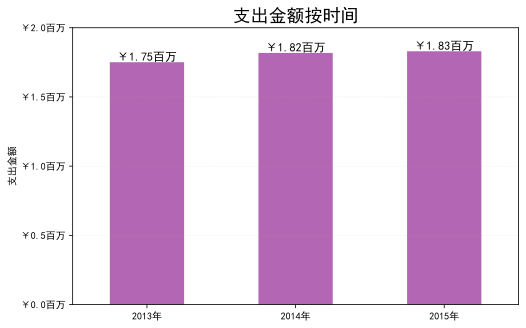

In [65]:
result.plot(
    figsize=(8,5),
    kind='bar',
    xlabel='',
    ylabel='支出金额',
    color='purple',
    alpha=0.6
)
plt.grid(axis='y',linestyle='--',linewidth=0.4,alpha=0.25)
plt.title('支出金额按时间',fontdict={'size':18})
plt.xticks(range(len(result)), [f'{year}年' for year in result.index], rotation=0)
plt.yticks([0, 0.5,1,1.5, 2], ['￥0.0百万', '￥0.5百万', '￥1.0百万','￥1.5百万','￥2.0百万'])

for i in range(result.size):
    plt.text(i,result.iloc[i]+0.01,f'￥{result.iloc[i]:.2f}百万',ha='center',fontdict={'size':12})

plt.show()

### 各科室接诊人次分析

In [66]:
department.head(3)

,科室,科室编号
0,儿科,K09
1,耳鼻咽喉科,K08
2,妇科,K10


In [67]:
doctor.head(3)

,医生编号,科室编号,医生名称,医生职称
0,Y180,K09,顾延,主治医师
1,Y181,K09,崔勇,主治医师
2,Y182,K09,顾建中,主治医师


In [68]:
visit.head(3)

,日期编号,病例编号,病症,患者登记地区,患者满意度,就诊类别,医生编号,治疗收入,治疗成本,药物成本
0,20150101,B76895,上呼吸道感染,江苏省,10,住院就诊,Y159,1040,846,30
1,20150101,B76896,冠心病,江苏省,9,普通门诊,Y160,1567,903,173
2,20150101,B76897,脑梗塞,江苏省,8,急诊,Y161,1277,709,219


In [69]:
temp2 = pd.merge(department,doctor,how='inner',on='科室编号')
temp2.head(3)

,科室,科室编号,医生编号,医生名称,医生职称
0,儿科,K09,Y180,顾延,主治医师
1,儿科,K09,Y181,崔勇,主治医师
2,儿科,K09,Y182,顾建中,主治医师


In [70]:
temp3 = pd.merge(temp2,visit,how='inner',on='医生编号')
temp3

,科室,科室编号,医生编号,医生名称,医生职称,日期编号,病例编号,病症,患者登记地区,患者满意度,就诊类别,治疗收入,治疗成本,药物成本
0,儿科,K09,Y180,顾延,主治医师,20150103,B77293,上呼吸道感染,北京市,10,急诊,1083,563,187
1,儿科,K09,Y180,顾延,主治医师,20150108,B78273,高血压,广东省,8,急诊,724,122,281
2,儿科,K09,Y180,顾延,主治医师,20150114,B79253,肺炎,重庆市,7,急诊,1483,972,212
3,儿科,K09,Y180,顾延,主治医师,20150119,B80233,脑梗塞后遗症,云南省,8,急诊,903,370,94
4,儿科,K09,Y180,顾延,主治医师,20150125,B81213,尿毒症,西藏自治区,8,普通门诊,951,604,238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123581,心脏科,K03,Y980,周翠娟,副主任医师,20130414,B32601,脑梗塞后遗症,浙江省,9,普通门诊,1379,929,261
123582,心脏科,K03,Y980,周翠娟,副主任医师,20130428,B33581,肺炎,上海市,7,普通门诊,1229,929,153
123583,心脏科,K03,Y980,周翠娟,副主任医师,20130442,B34561,支气管炎,广东省,7,普通门诊,1283,558,266
123584,心脏科,K03,Y980,周翠娟,副主任医师,20130454,B35541,胃炎,北京市,8,急诊,621,179,226


In [71]:
temp4 = temp3.groupby('科室')['科室'].count()
temp5 = temp4.sort_values(ascending=False)
temp5

科室
皮肤科      24570
口腔科      20160
外科       13734
内科       12446
心脏科      11718
儿科       11214
骨科        8828
耳鼻咽喉科     8694
内分泌科      6174
妇科        6048
Name: 科室, dtype: int64

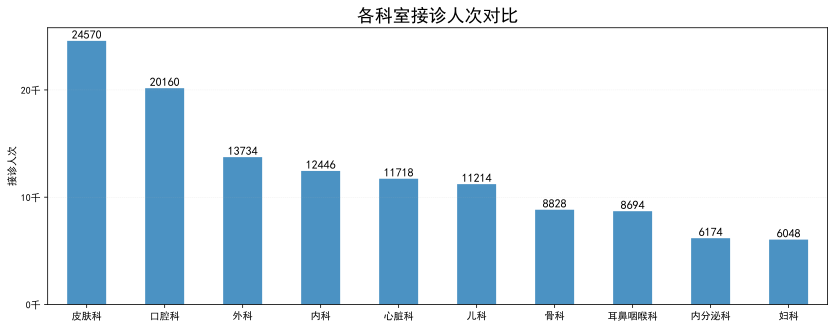

In [72]:
temp5.plot(
    figsize=(14,5),
    kind='bar',
    xlabel='',
    ylabel='接诊人次',
    alpha=0.8
)
plt.grid(axis='y',linestyle='--',linewidth=0.4,alpha=0.25)
plt.title('各科室接诊人次对比',fontdict={'size':18})
plt.xticks(rotation=0)
plt.yticks([0, 10000, 20000], ['0千', '10千', '20千'])

for i in range(temp5.size):
    plt.text(i,temp5.iloc[i]+200,temp5.iloc[i],ha='center',fontdict={'size':12})

plt.show()

### 就诊人数分析

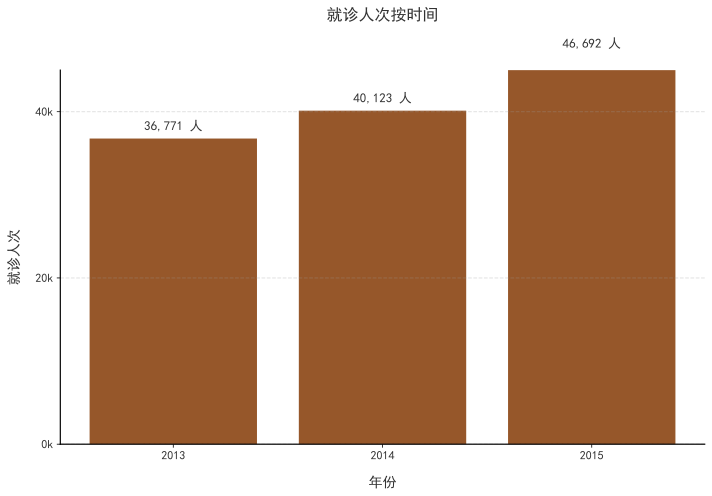

In [73]:
# 按日期编号统计每日就诊人次
daily_visits = visit.groupby('日期编号').size().reset_index(name='就诊人次')
# 合并日期信息并提取年份
daily_visits['日期编号_str'] = daily_visits['日期编号'].astype(str)
date['日期编号_str'] = date['日期编号'].astype(str)
daily_visits = pd.merge(daily_visits, date[['日期编号_str', '日期']], on='日期编号_str', how='left')
daily_visits['年份'] = daily_visits['日期'].dt.year
# 按年份聚合总就诊人次
yearly_visits = daily_visits.groupby('年份')['就诊人次'].sum().reset_index()

# 2. 绘制柱状图（核心：去边框、仅显x/y轴、标题升高）
plt.figure(figsize=(10, 7))
ax = plt.gca()  # 获取坐标轴对象，用于精细控制

# 绘制土色柱子（去除边框：linewidth=0）
bars = plt.bar(
    x=yearly_visits['年份'].astype(str),
    height=yearly_visits['就诊人次'],
    color='#8B4513',  # 土色
    alpha=0.9,
    linewidth=0,      # 关键：去掉柱子边框
    edgecolor='none'  # 双重保障：边框颜色设为无
)

# 3. 坐标轴控制：仅显示x轴和y轴，隐藏其他边框
# 隐藏顶部和右侧边框（spines对应四个边框：top/right/bottom/left）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# 保留底部（x轴）和左侧（y轴）边框，可调整线条粗细增强显示
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)

# 4. y轴设置：仅0k/20k/40k，刻度标签优化
ax.set_yticks([0, 20000, 40000])
ax.set_yticklabels(['0k', '20k', '40k'], fontsize=12, fontweight='bold', color='#333333')
ax.set_ylim(0, 45000)  # 留出顶部标签空间
ax.set_ylabel('就诊人次', fontsize=14, fontweight='bold', color='#333333', labelpad=15)

# 5. x轴设置：年份显示+顶部原始人数标签
ax.set_xticks(yearly_visits['年份'].astype(str))
ax.set_xticklabels(yearly_visits['年份'].astype(str), fontsize=12, fontweight='bold', color='#333333')
ax.set_xlabel('年份', fontsize=14, fontweight='bold', color='#333333', labelpad=15)

# 柱子顶部显示原始人数（不用k单位）
for bar, raw_count in zip(bars, yearly_visits['就诊人次']):
    plt.text(
        x=bar.get_x() + bar.get_width()/2,
        y=bar.get_height() + 800,
        s=f'{raw_count:,} 人',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='#333333'
    )

# 6. 标题升高：通过pad参数增加标题与图表的间距（默认pad=10，此处设为30）
plt.title(
    '就诊人次按时间',
    fontsize=16,
    fontweight='bold',
    color='#333333',
    pad=50  # 关键：pad值越大，标题位置越高
)
# 7. 保留水平网格线（辅助读数，不干扰主体）
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1, color='#999999')
# 调整布局，确保所有元素显示完整
plt.tight_layout()
# 保存图表
plt.show()

### 患者满意度分析

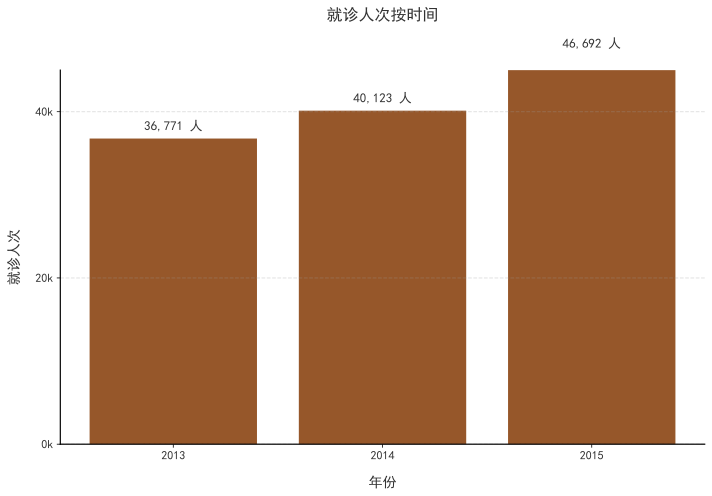

In [87]:
# 按日期编号统计每日就诊人次
daily_visits = visit.groupby('日期编号').size().reset_index(name='就诊人次')
# 合并日期信息并提取年份
daily_visits['日期编号_str'] = daily_visits['日期编号'].astype(str)
date['日期编号_str'] = date['日期编号'].astype(str)
daily_visits = pd.merge(daily_visits, date[['日期编号_str', '日期']], on='日期编号_str', how='left')
daily_visits['年份'] = daily_visits['日期'].dt.year
# 按年份聚合总就诊人次
yearly_visits = daily_visits.groupby('年份')['就诊人次'].sum().reset_index()

# 2. 绘制柱状图（核心：去边框、仅显x/y轴、标题升高）
plt.figure(figsize=(10, 7))
ax = plt.gca()  # 获取坐标轴对象，用于精细控制

# 绘制土色柱子（去除边框：linewidth=0）
bars = plt.bar(
    x=yearly_visits['年份'].astype(str),
    height=yearly_visits['就诊人次'],
    color='#8B4513',  # 土色
    alpha=0.9,
    linewidth=0,      # 关键：去掉柱子边框
    edgecolor='none'  # 双重保障：边框颜色设为无
)

# 3. 坐标轴控制：仅显示x轴和y轴，隐藏其他边框
# 隐藏顶部和右侧边框（spines对应四个边框：top/right/bottom/left）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# 保留底部（x轴）和左侧（y轴）边框，可调整线条粗细增强显示
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)

# 4. y轴设置：仅0k/20k/40k，刻度标签优化
ax.set_yticks([0, 20000, 40000])
ax.set_yticklabels(['0k', '20k', '40k'], fontsize=12, fontweight='bold', color='#333333')
ax.set_ylim(0, 45000)  # 留出顶部标签空间
ax.set_ylabel('就诊人次', fontsize=14, fontweight='bold', color='#333333', labelpad=15)

# 5. x轴设置：年份显示+顶部原始人数标签
ax.set_xticks(yearly_visits['年份'].astype(str))
ax.set_xticklabels(yearly_visits['年份'].astype(str), fontsize=12, fontweight='bold', color='#333333')
ax.set_xlabel('年份', fontsize=14, fontweight='bold', color='#333333', labelpad=15)

# 柱子顶部显示原始人数（不用k单位）
for bar, raw_count in zip(bars, yearly_visits['就诊人次']):
    plt.text(
        x=bar.get_x() + bar.get_width()/2,
        y=bar.get_height() + 800,
        s=f'{raw_count:,} 人',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='#333333'
    )

# 6. 标题升高：通过pad参数增加标题与图表的间距（默认pad=10，此处设为30）
plt.title(
    '就诊人次按时间',
    fontsize=16,
    fontweight='bold',
    color='#333333',
    pad=50  # 关键：pad值越大，标题位置越高
)
# 7. 保留水平网格线（辅助读数，不干扰主体）
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1, color='#999999')
# 调整布局，确保所有元素显示完整
plt.tight_layout()
# 保存图表
plt.show()

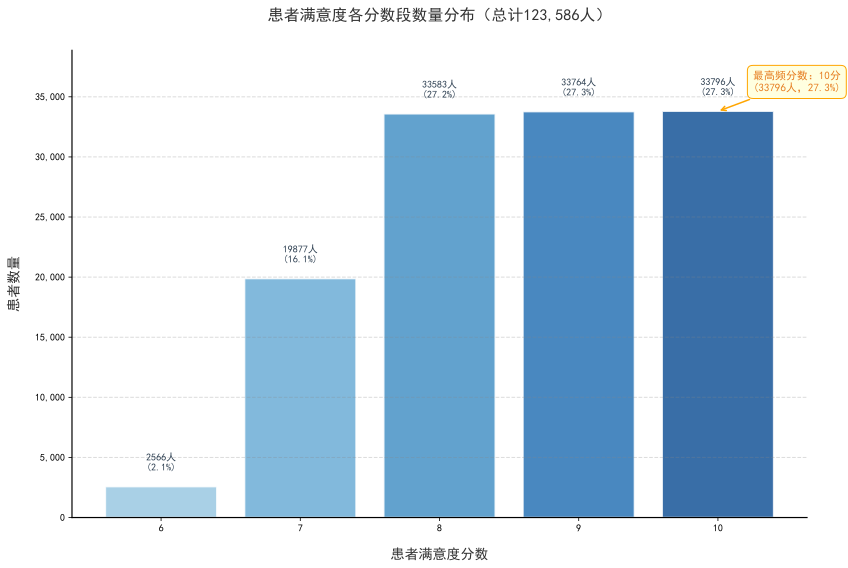

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# 基础配置：中文显示、负号正常显示、矢量图输出
plt.rcParams['font.sans-serif'].insert(0, 'SimHei')
plt.rcParams['axes.unicode_minus'] = False
# 提取并清洗满意度数据
satisfaction_data = visit[satisfaction_col].dropna()
satisfaction_data = pd.to_numeric(satisfaction_data, errors='coerce').dropna()
satisfaction_data = satisfaction_data.astype(int)  # 转为整数分数
# 过滤不合理的分数范围（假设合理范围为0-10分）
min_valid = 0
max_valid = 10
satisfaction_data = satisfaction_data[
    (satisfaction_data >= min_valid) & 
    (satisfaction_data <= max_valid)
]
# 3. 统计各分数的数量分布
# 按分数升序排列
score_count = satisfaction_data.value_counts().sort_index().reset_index()
score_count.columns = ['分数', '数量']
# 确保所有可能的分数段都存在（填充缺失分数为0）
min_score = int(satisfaction_data.min())
max_score = int(satisfaction_data.max())
all_scores = pd.DataFrame({'分数': range(min_score, max_score + 1)})
score_count = pd.merge(all_scores, score_count, on='分数', how='left').fillna(0)
score_count['数量'] = score_count['数量'].astype(int)  # 数量转为整数
# 4. 计算额外统计信息（用于图表标注）
total_count = score_count['数量'].sum()
score_count['占比(%)'] = (score_count['数量'] / total_count * 100).round(1)
most_common_idx = score_count['数量'].idxmax()
most_common_score = score_count.loc[most_common_idx, '分数']
most_common_count = score_count['数量'].max()
most_common_rate = score_count.loc[most_common_idx, '占比(%)']
# 计算平均满意度
avg_score = (score_count['分数'] * score_count['数量']).sum() / total_count
avg_score_rounded = round(avg_score, 1)
# 5. 绘制满意度各分数数量柱状图
plt.figure(figsize=(12, 8))
ax = plt.gca()
# 定义专业配色：蓝色系渐变（分数越高，颜色越深）
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(score_count)))
# 绘制柱状图
bars = ax.bar(
    x=score_count['分数'].astype(str),  # x轴分数转为字符串
    height=score_count['数量'],
    color=colors,
    alpha=0.8,
    edgecolor='white',
    linewidth=1.5
)

# 6. 图表细节优化
# 添加数量和占比标签
for bar, count, rate in zip(bars, score_count['数量'], score_count['占比(%)']):
    height = bar.get_height()
    if count > 0:  # 仅显示有数据的标签
        ax.text(
            x=bar.get_x() + bar.get_width()/2,
            y=height + total_count * 0.01,  # 动态调整标签高度
            s=f'{count}人\n({rate}%)',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color='#2C3E50'
        )

# 标注最高频分数
ax.annotate(
    f'最高频分数：{most_common_score}分\n({most_common_count}人，{most_common_rate}%)',
    xy=(most_common_idx, most_common_count),  # 标注位置（对应柱子索引）
    xytext=(35, 20),  # 文本偏移量
    textcoords='offset points',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='orange'),
    arrowprops=dict(arrowstyle='->', color='orange', lw=1.5),
    fontsize=11,
    fontweight='bold',
    color='#E67E22'
)

# 坐标轴与标题设置
ax.set_xlabel(
    '患者满意度分数',
    fontsize=14,
    fontweight='bold',
    labelpad=15,
    color='#333333'
)
ax.set_ylabel(
    '患者数量',
    fontsize=14,
    fontweight='bold',
    labelpad=15,
    color='#333333'
)
ax.set_title(
    f'患者满意度各分数段数量分布（总计{total_count:,}人）',
    fontsize=16,
    fontweight='bold',
    pad=30,
    color='#333333'
)

# 简化边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)

# y轴刻度优化
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
y_max = score_count['数量'].max() * 1.15  # 预留标签空间
ax.set_ylim(0, y_max)

# 网格线设置
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1, color='#888888')

# 调整布局
plt.tight_layout()

# 保存图表（可选）
# plt.savefig('患者满意度分布.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()